In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Чтение датасета и предварительный просмотр

In [11]:
df = pd.read_csv('D:Загрузки/archive/Churn_Modelling.csv')

In [4]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Посмотрим на пропущенные значения

In [8]:
df.isna().value_counts()

RowNumber  CustomerId  Surname  CreditScore  Geography  Gender  Age    Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
False      False       False    False        False      False   False  False   False    False          False      False           False            False     10000
Name: count, dtype: int64

Уберем неинформативные признаки и закодируем категориальные

In [12]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head(5)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df = pd.get_dummies(df)
df.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


Оценим корреляцию между признаками

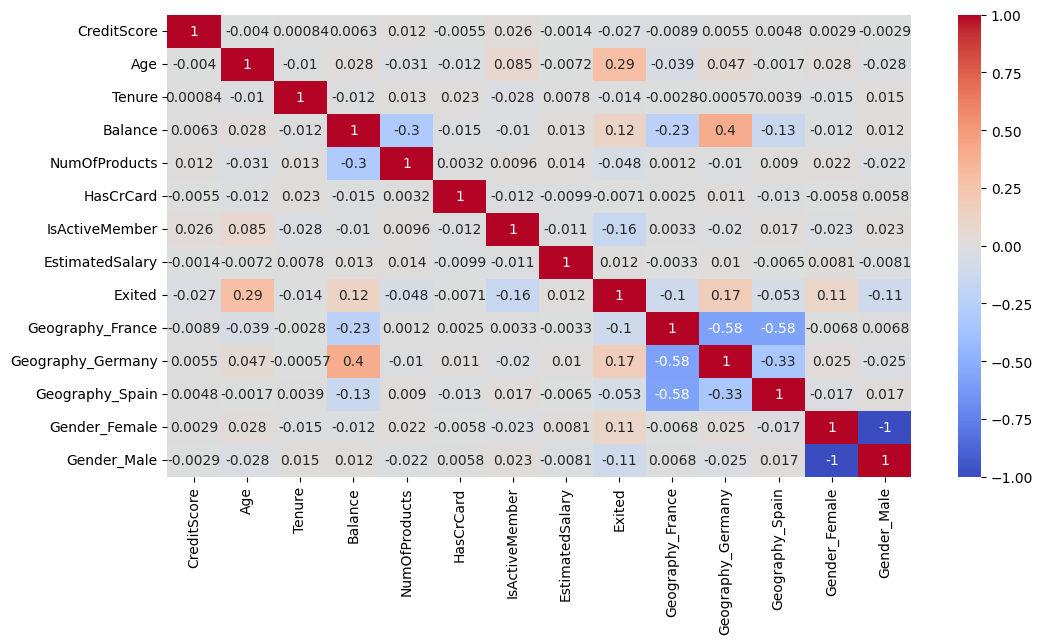

In [16]:
corr = df.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.show()

Сильной корреляции признаков с таргетом не обнаружено. Также нет сильно коррелирующих между собой признаков

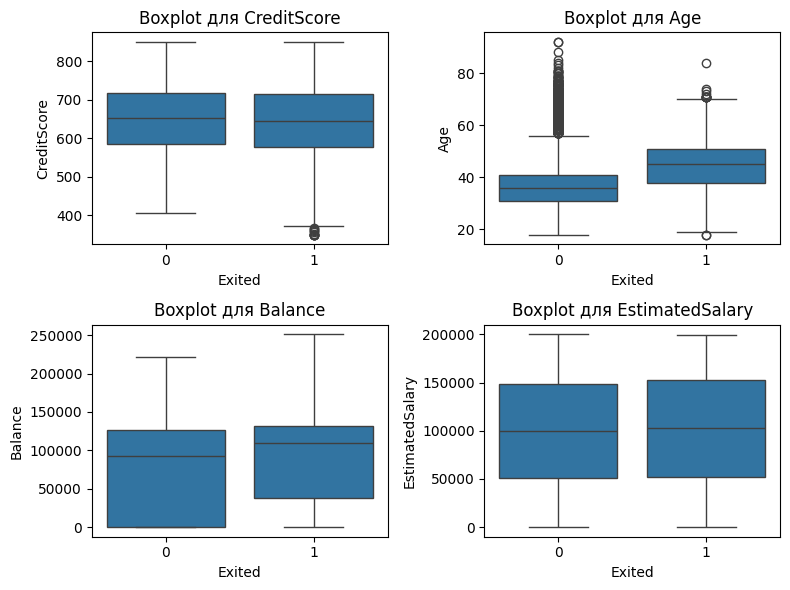

In [29]:
numeric_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
plt.figure(figsize=(8, 6))
for i, col in enumerate(numeric_cols):  # только числовые признаки
    plt.subplot(2,2,i+1)
    sns.boxplot(x='Exited', y=col, data=df)
    plt.title(f'Boxplot для {col}')
plt.tight_layout()
plt.show()

### Стандартизуем данные для линейной модели

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scalled = pd.DataFrame(scaler.fit_transform(df[cols]), columns=numeric_cols)
cat_features = [col for col in df.columns if col not in numeric_cols]
df_scalled = pd.concat([df_scalled,df[cat_features]], axis=1)

In [35]:
df_scalled.head(5)

,CreditScore,Age,Balance,EstimatedSalary,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.326221,0.293517,-1.225848,0.021886,2,1,1,1,1,True,False,False,True,False
1,-0.440036,0.198164,0.117350,0.216534,1,1,0,1,0,False,False,True,True,False
2,-1.536794,0.293517,1.333053,0.240687,8,3,1,0,1,True,False,False,True,False
3,0.501521,0.007457,-1.225848,-0.108918,1,2,0,0,0,True,False,False,True,False
4,2.063884,0.388871,0.785728,-0.365276,2,1,1,1,0,False,False,True,True,False


### Разделение на тренировочную и тестовую выборку

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [43]:
X = df_scalled.drop('Exited', axis=1)
y = df_scalled['Exited']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

### Логистическая регрессия

In [52]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight':['balanced']
}

model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)

Лучшие параметры: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


In [53]:
best_logistic = grid.best_estimator_
y_pred = best_logistic.predict(X_test)

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.39      0.72      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



Метрики, которые нас интересуют больше всего это - Recall и F1. Recall показывает как много клиентов из тех, которые собираются уйти, наша модель может предсказать. F1 - это среднее гармоническое между Precision и Recall. F1 - позволяет учитывать не только полноту наших предсказаний, но и их точность, что позволяет не тратить ресурсы компании на тех клиентов, которые уходить не собираются. Так как в нашем случае наблюдается дисбаланс классов (393vs1607), то accuracy будет плохой метрикой. Она не учитывает дисбаланс классов и даже при плохом предсказании на минорном классе будет показывать удовлетворительные показатели

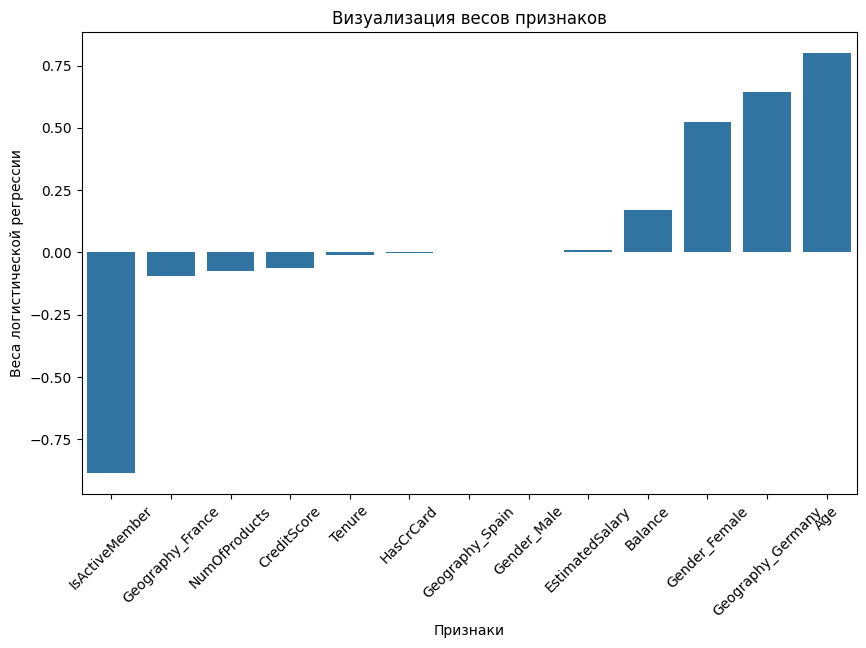

In [68]:
weights = grid.best_estimator_.coef_[0]  
features = X.columns      
weight = pd.DataFrame({'feature': features, 'weight': weights})
sorted_features = weight.sort_values('weight')['feature']
plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='weight', data=weight, order=sorted_features)
plt.xlabel('Признаки')
plt.ylabel('Веса логистической регрессии')
plt.title('Визуализация весов признаков')
plt.xticks(rotation=45)
plt.show()

Веса логистической регрессии показывают важность признаков, по которым модель предсказывает результат. Топ 3 признака: Возраст, Является ли клиент активным членом и страна клиента(Германия). Если веса положительные, то увеличение значений признака приводит к увеличению прогнозируемого отклика. Т.е. увеличение возраста клиентов и их страна(Германия) говорят и том, они в скором времени могут уйти. Признак "активный член" наоборот имеет отрицательные веса, поэтому чем больше его значения, тем менее вероятнее клиент уйдет.

### Дерево решений

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [83]:
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [84]:
param_grid = {
    'max_depth': [1, 2, 3, 5],
    'min_samples_leaf': [10, 20, 30],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'), 
    param_grid, 
    cv=5, 
    scoring='f1'
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Лучшие параметры:", grid_search.best_params_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20}


In [85]:
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82      1607
           1       0.42      0.81      0.55       393

    accuracy                           0.74      2000
   macro avg       0.68      0.77      0.68      2000
weighted avg       0.84      0.74      0.76      2000



Метрики решающего дерева лучше, чем метрики логистической регрессии. Произошло увелечение как Recall, так и Precision и соответственно F1.

Изобразим дерево. Так как глубина дерева 5, то отображаться оно будет уже не очень привлекательно

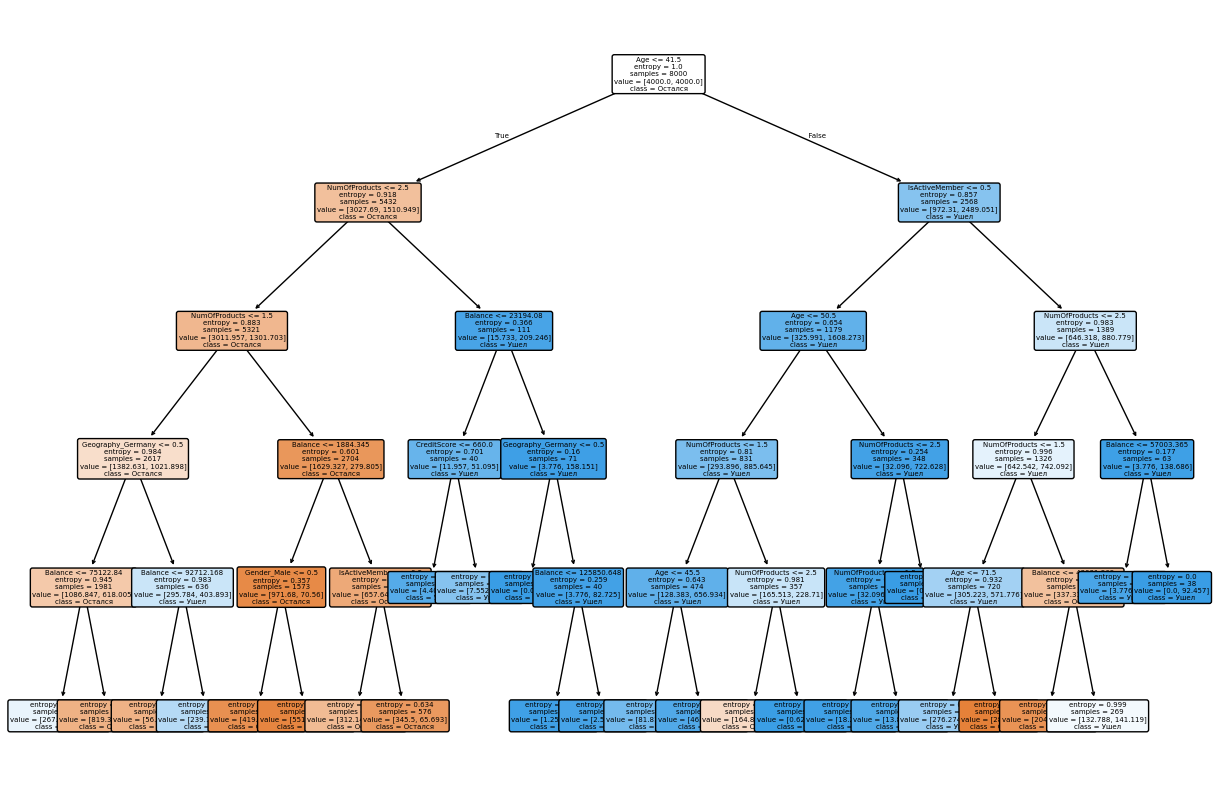

In [86]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(
    grid_search.best_estimator_, 
    feature_names=X.columns, 
    class_names=['Остался', 'Ушел'], 
    filled=True, 
    rounded=True,
    fontsize=5
)
plt.show()

Посмотрим на важность признаков

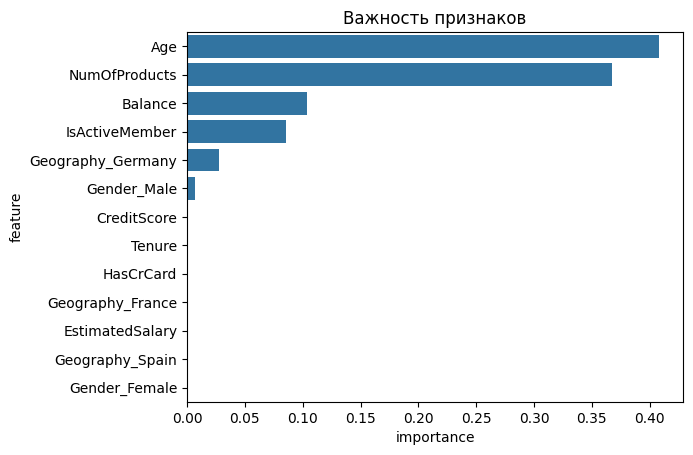

In [87]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Важность признаков')
plt.show()


Топ 3 признака для дерева решений: Возраст (как и у линейной регрессии), количество продуктов, которые использует клиент (у регресси не было, но звучит логично), размер банковского счета (у регрессии также не было)

### Случайный лес

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [89]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Лучшие параметры:", grid_search.best_params_)
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1607
           1       0.49      0.77      0.60       393

    accuracy                           0.80      2000
   macro avg       0.71      0.79      0.73      2000
weighted avg       0.85      0.80      0.81      2000



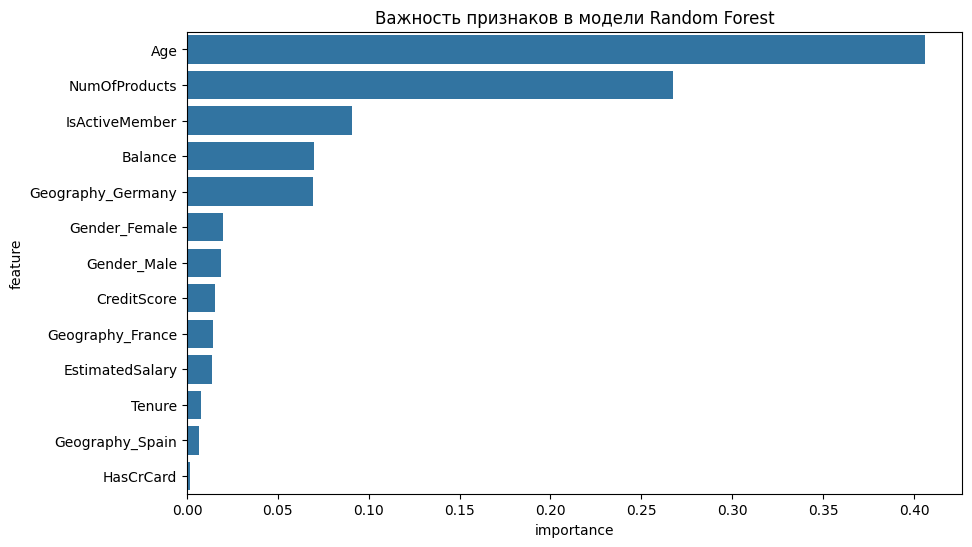

In [90]:
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': grid_search.best_estimator_.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Важность признаков в модели Random Forest')
plt.show()

Важность признаков здесь почти такая же как и для одиночного дерева. Единственное третье место теперь занимает признак "Является ли активным членом", а не баланс, как было у дерева решений

### Выводы

В задаче я использовал три модели: лог регрессию, дерево решений и ансабль деревьев:случайный лес. Так как задача была построить интерпретируюмую модель, то использовать бустинг и другие методы я не стал. Исходя из нашей задачи наиболее оптимальной метрикой, по которой надо сравнивать модели, я считаю Recall, так как она показывает какую долю клиентов (собирающихся уйти) модель может обнаружить, а банк соответсвенно на них повлиять. По этой метрике лучшей моделью является дерево решений глубиной 5 и минимальным количеством объектов в листьях 20. Дерево глубиной 5 обладает достаточной глубиной для обеспечения достаточной предсказательной способности и при этом не слишком глубокое для понимания человеком